# Bismillah 
- Setting up My WorkSpace
- And Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1. main eik sath he data sets ko load kar raha hun alag alag
# variable ka use krte hue

customers = pd.read_excel('customers.xlsx')
geography = pd.read_excel('geography.xlsx')
products = pd.read_excel('products.xlsx')
reviews = pd.read_excel('customer_reviews.xlsx')
engagement = pd.read_excel('engagement_data.xlsx')
journey = pd.read_excel('customer_journey.xlsx')

# Step 2: Clean the 'Engagement Data' (Crucial Step!)

In [3]:
# Create a copy to clean
engagement_clean = engagement.copy()

In [4]:
engagement_clean.head(20)

,EngagementID,ContentID,ContentType,Likes,EngagementDate,CompaignID,ProductID,ViewsClickCombined
0,1,39,Blog,190,2023-08-30,1,9,1883-671
1,2,48,Blog,114,2023-03-28,18,20,5280-532
2,3,16,video,32,2023-12-08,7,14,1905-204
3,4,43,Video,17,2025-01-21,19,20,2766-257
4,5,16,newsletter,306,2024-02-21,6,15,5116-1524
5,6,32,Socialmedia,648,2023-06-18,18,19,8237-1641
6,7,33,SOCIALMEDIA,1,2025-10-01,12,2,750-34
7,8,47,Blog,1,2025-03-31,17,6,891-35
8,9,48,blog,123,2024-03-19,13,16,5571-1527
9,10,4,Blog,25,2023-12-03,15,15,4279-297


In [5]:
engagement_clean['ViewsClickCombined'].value_counts

<bound method IndexOpsMixin.value_counts of 0        1883-671
1        5280-532
2        1905-204
3        2766-257
4       5116-1524
          ...    
4618    8115-1872
4619     1273-516
4620     1609-599
4621     3052-374
4622     2458-457
Name: ViewsClickCombined, Length: 4623, dtype: object>

### Remove the two error rows containing date-like entries (e.g., '2000-10-01 00:00:00')

In [6]:
engagement_clean = engagement_clean[~engagement_clean['ViewsClickCombined'].astype(str).str.contains(':')]

### Split the column by the hyphen '~'

In [7]:
split_data = engagement_clean['ViewsClickCombined'].str.split('-', expand=True)
engagement_clean['Views'] = split_data[0].astype(int)
engagement_clean['Clicks'] = split_data[1].astype(int)

### Now engagement_clean has beautiful, numeric 'Views' and 'Clicks' columns!

In [8]:
print(engagement_clean[['Views', 'Clicks']].head())

   Views  Clicks
0   1883     671
1   5280     532
2   1905     204
3   2766     257
4   5116    1524


In [9]:
engagement_clean.head()

,EngagementID,ContentID,ContentType,Likes,EngagementDate,CompaignID,ProductID,ViewsClickCombined,Views,Clicks
0,1,39,Blog,190,2023-08-30,1,9,1883-671,1883,671
1,2,48,Blog,114,2023-03-28,18,20,5280-532,5280,532
2,3,16,video,32,2023-12-08,7,14,1905-204,1905,204
3,4,43,Video,17,2025-01-21,19,20,2766-257,2766,257
4,5,16,newsletter,306,2024-02-21,6,15,5116-1524,5116,1524


# Step 3: Understand How the Files Connect (Data Model)
- Customers & Geography: Connect customers and geography using GeographyID from customers and ID from geography.

- Reviews & Customers/Products: Connect reviews with customers using CustomerID, and with products using ProductID.

- Journey & Customers/Products: Connect journey with customers on CustomerID, and with products on ProductId (note the lowercase 'd'!).

In [11]:
customers_geo = pd.merge(
    customers, 
    geography, 
    left_on='GeographyID', 
    right_on='ID', 
    how='left')
customers_geo = customers_geo.drop(columns=['ID'])

In [13]:
full_reviews = pd.merge(
    reviews, 
    customers_geo, 
    on='CustomerID', 
    how='left')
full_reviews = pd.merge(
    full_reviews, 
    products, 
    on='ProductID', 
    how='left')

In [14]:
print("✅ Saara data clean aur merge ho chuka hai! Ab hum Questions start kar sakte hain.")

✅ Saara data clean aur merge ho chuka hai! Ab hum Questions start kar sakte hain.


# Let's Do the First Question
- Total kitne unique customers hain?

In [15]:
# Question 1
total_unique_customers = customers['CustomerID'].nunique()
print(f"Total Unique Customers: {total_unique_customers}")

Total Unique Customers: 100


In [16]:
# Question 2
# Age bins aur labels define karte hain
bins = [0, 30, 55, 100]
labels = ['Young', 'Adult', 'Senior']

# Naya column 'AgeCategory' banate hain
customers_geo['AgeCategory'] = pd.cut(customers_geo['Age'], bins=bins, labels=labels)

# Distribution check karte hain
age_distribution = customers_geo['AgeCategory'].value_counts()
print("Age Category Distribution:")
print(age_distribution)

Age Category Distribution:
AgeCategory
Adult     55
Young     24
Senior    21
Name: count, dtype: int64


In [17]:
# Question 3
gender_distribution = customers_geo['Gender'].value_counts()
print("Gender Distribution:")
print(gender_distribution)

Gender Distribution:
Gender
Female    54
Male      46
Name: count, dtype: int64


In [19]:
# Question 4
avg_rating_age = full_reviews.groupby('AgeCategory')['Rating'].mean()
print("Average Rating by Age Category:")
print(avg_rating_age)

KeyError: 'AgeCategory'

In [20]:
# Question 5
avg_purchase_gender = full_reviews.groupby('Gender')['Price'].mean()
print("Average Purchase Value by Gender:")
print(avg_purchase_gender)

Average Purchase Value by Gender:
Gender
Female    199.548996
Male      202.839553
Name: Price, dtype: float64


In [21]:
# Question 6
customer_country_counts = customers_geo['Region'].value_counts()
print("Customers per Country:")
print(customer_country_counts)
print(f"\n🏆 Sabse zyada customers is country mein hain: {customer_country_counts.index[0]}")

Customers per Country:
Region
Spain          18
Italy          12
Germany        11
Austria        10
UK             10
Netherlands     9
Belgium         9
Sweden          8
Switzerland     8
France          5
Name: count, dtype: int64

🏆 Sabse zyada customers is country mein hain: Spain


In [22]:
# Question 7
avg_rating_country = full_reviews.groupby('Region')['Rating'].mean()
print("Average Review Rating by Country:")
print(avg_rating_country)

Average Review Rating by Country:
Region
Austria        3.654867
Belgium        3.584615
France         3.754098
Germany        3.744681
Italy          3.675497
Netherlands    3.687943
Spain          3.774319
Sweden         3.689655
Switzerland    3.490741
UK             3.717241
Name: Rating, dtype: float64


In [23]:
# Question 8
# Journey data ko customer profiles ke sath merge karte hain
journey_cust = pd.merge(journey, customers_geo, on='CustomerID', how='left')

# Average duration nikalte hain per country
avg_engagement_country = journey_cust.groupby('Region')['Duration'].mean()
print("Average Engagement Score (Duration) by Country:")
print(avg_engagement_country)

Average Engagement Score (Duration) by Country:
Region
Austria        153.670968
Belgium        151.406557
France         154.824176
Germany        157.663130
Italy          159.231579
Netherlands    157.232787
Spain          155.379471
Sweden         155.055336
Switzerland    161.470990
UK             158.528571
Name: Duration, dtype: float64


In [24]:
# Question 9
avg_engagement_age = journey_cust.groupby('AgeCategory')['Duration'].mean()
print("Average Engagement Score (Duration) by Age Category:")
print(avg_engagement_age)

# Highest group print karte hain
highest_group = avg_engagement_age.idxmax()
print(f"\n🏆 Sabse zyada engagement is age group ki hai: {highest_group}")

Average Engagement Score (Duration) by Age Category:
AgeCategory
Young     158.516089
Adult     155.794054
Senior    156.124324
Name: Duration, dtype: float64

🏆 Sabse zyada engagement is age group ki hai: Young


/tmp/ipykernel_12571/1268462577.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_engagement_age = journey_cust.groupby('AgeCategory')['Duration'].mean()


Average Ratings by Gender:
Gender
Female    3.654003
Male      3.725240
Name: Rating, dtype: float64


/tmp/ipykernel_12571/1469066212.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=full_reviews, x='Gender', y='Rating', errorbar=None, palette='muted')


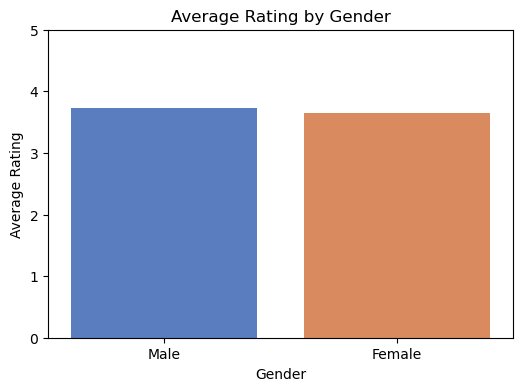

In [25]:
# Question 10
# Average rating calculate karna
avg_rating_gender = full_reviews.groupby('Gender')['Rating'].mean()
print("Average Ratings by Gender:")
print(avg_rating_gender)

# Bar chart visualize karna
plt.figure(figsize=(6, 4))
sns.barplot(data=full_reviews, x='Gender', y='Rating', errorbar=None, palette='muted')
plt.title('Average Rating by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Rating')
plt.ylim(0, 5) # Rating scale 1-5 hota hai
plt.show()

# Part 2: Product Analysis (Questions 11 - 20)

In [26]:
# Q11: Top 10 products purchased
purchases = journey[journey['Action'].str.lower() == 'purchase']
top_10_purchased = purchases.groupby('ProductId').size().sort_values(ascending=False).head(10)

# Q12: Sabse zyada reviews kis product ko mile hain
top_reviewed = reviews['ProductID'].value_counts().head(5)

# Q13: Sabse zyada engagement wale Top 10 products
engagement_clean['TotalEngagement'] = engagement_clean['Views'] + engagement_clean['Clicks'] + engagement_clean['Likes']
top_10_engaged = engagement_clean.groupby('ProductID')['TotalEngagement'].sum().sort_values(ascending=False).head(10)

print("Top 10 Purchased Product IDs:\n", top_10_purchased)
print("\nTop Reviewed Product IDs:\n", top_reviewed)
print("\nTop 10 Engaged Product IDs:\n", top_10_engaged)

Top 10 Purchased Product IDs:
 ProductId
19    15
12    13
11    13
9     13
15    12
17    12
14    12
2     11
16    10
10    10
dtype: int64

Top Reviewed Product IDs:
 ProductID
12    79
2     76
4     75
16    75
5     75
Name: count, dtype: int64

Top 10 Engaged Product IDs:
 ProductID
7     833441
1     831048
15    800693
12    792697
13    792623
5     780937
10    765436
6     747447
16    738121
3     726991
Name: TotalEngagement, dtype: int64


In [27]:
# Q14: Category wise average rating
print(full_reviews.groupby('Category')['Rating'].mean())

# Q15 & 16: Category wise engagement metrics
eng_prod = pd.merge(engagement_clean, products, on='ProductID', how='left')
print(eng_prod.groupby('Category')[['TotalEngagement', 'Views', 'Clicks']].mean())

Category
Sports    3.68672
Name: Rating, dtype: float64
          TotalEngagement        Views      Clicks
Category                                          
Sports        3158.462887  2545.892664  498.152132


In [29]:
# Question 17 - 18: Lowest & Highest Rated Top 10 Products

prod_rating = full_reviews.groupby('ProductID')['Rating'].mean()
print("Lowest Rated 10 Products:\n", prod_rating.sort_values().head(10))
print("\nHighest Rated 10 Products:\n", prod_rating.sort_values(ascending=False).head(10))

Lowest Rated 10 Products:
 ProductID
10    3.484375
3     3.523077
6     3.555556
1     3.571429
18    3.576271
20    3.610169
4     3.626667
17    3.652778
19    3.666667
5     3.666667
Name: Rating, dtype: float64

Highest Rated 10 Products:
 ProductID
15    3.913043
13    3.835616
14    3.803571
16    3.786667
7     3.781250
2     3.776316
11    3.731343
9     3.726027
8     3.703125
12    3.696203
Name: Rating, dtype: float64


/tmp/ipykernel_12571/4163669208.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pop_series.values, y=pop_series.index, palette='viridis')


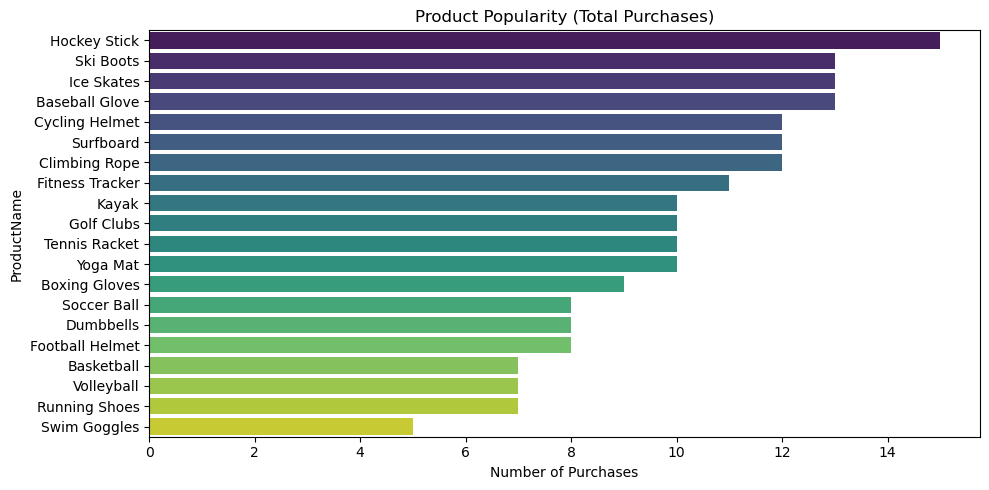

In [30]:
# Question 19 - 20: Product Popularity Graph

# Q20: Product popularity chart based on total purchases
purchases_df = pd.merge(purchases, products, left_on='ProductId', right_on='ProductID', how='left')
pop_series = purchases_df['ProductName'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=pop_series.values, y=pop_series.index, palette='viridis')
plt.title('Product Popularity (Total Purchases)')
plt.xlabel('Number of Purchases')
plt.tight_layout()
plt.show()

# 📈 Part 3: Engagement Analysis (Questions 21 - 28)

In [31]:
# Question 21 - 23: Engagement Rates & Totals

# Q21: Total Views, Clicks, Likes
total_views = engagement_clean['Views'].sum()
total_clicks = engagement_clean['Clicks'].sum()
total_likes = engagement_clean['Likes'].sum()

# Q22: Overall Engagement Rate (Clicks + Likes out of Total Views)
overall_er = ((total_clicks + total_likes) / total_views) * 100

print(f"Total Views: {total_views}, Total Clicks: {total_clicks}, Total Likes: {total_likes}")
print(f"Overall Engagement Rate: {overall_er:.2f}%")

Total Views: 11764570, Total Clicks: 2301961, Total Likes: 528726
Overall Engagement Rate: 24.06%


In [32]:
# Question 24 - 25: Most & Least Engaged Products
prod_engagement_summary = engagement_clean.groupby('ProductID')['TotalEngagement'].sum().sort_values()
print("Least Engaged Products:\n", prod_engagement_summary.head(5))
print("\nMost Engaged Products:\n", prod_engagement_summary.tail(5))

Least Engaged Products:
 ProductID
2     609363
17    628303
8     660221
14    665989
11    666459
Name: TotalEngagement, dtype: int64

Most Engaged Products:
 ProductID
13    792623
12    792697
15    800693
1     831048
7     833441
Name: TotalEngagement, dtype: int64


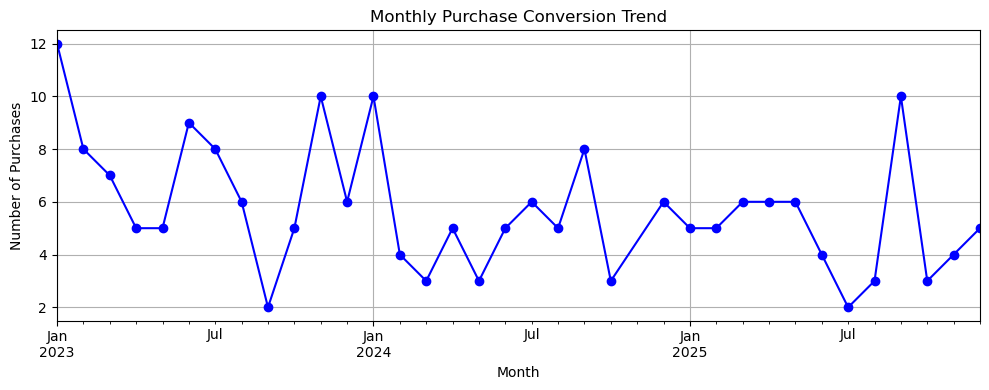

In [34]:
# Question 26: Conversion Trend Line Graph

# Monthly conversion trend visualization
journey['VisitDate'] = pd.to_datetime(journey['VisitDate'])
journey['Month'] = journey['VisitDate'].dt.to_period('M')
monthly_trend = journey[journey['Action'].str.lower() == 'purchase'].groupby('Month').size()

plt.figure(figsize=(10, 4))
monthly_trend.plot(kind='line', marker='o', color='b')
plt.title('Monthly Purchase Conversion Trend')
plt.xlabel('Month')
plt.ylabel('Number of Purchases')
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
# Question 27 - 28: Campaign Performance (CTR)

# Click-Through Rate per Campaign
camp_ctr = engagement_clean.groupby('CompaignID')[['Views', 'Clicks']].sum()
camp_ctr['CTR (%)'] = (camp_ctr['Clicks'] / camp_ctr['Views']) * 100
sorted_ctr = camp_ctr['CTR (%)'].sort_values(ascending=False)

print("Top Performing Campaigns (Highest CTR):\n", sorted_ctr.head(3))
print("\nLowest Performing Campaigns (Lowest CTR):\n", sorted_ctr.tail(3))

Top Performing Campaigns (Highest CTR):
 CompaignID
16    21.441536
18    21.106271
4     20.773298
Name: CTR (%), dtype: float64

Lowest Performing Campaigns (Lowest CTR):
 CompaignID
19    18.580621
12    17.264409
1     17.263579
Name: CTR (%), dtype: float64


# 🔗 Part 4: Combined Analysis (Questions 29 - 30)

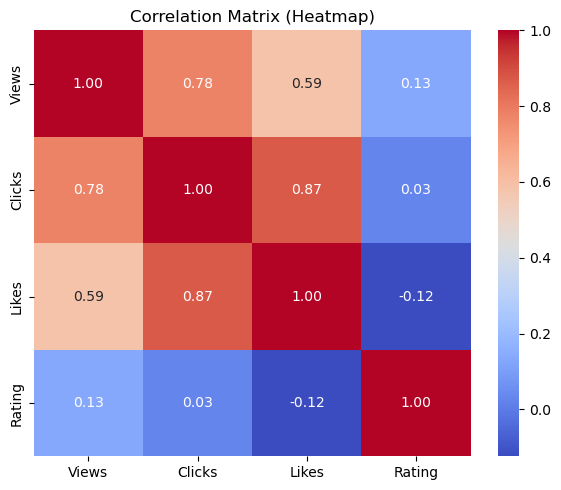

In [36]:
# Q29 & 30: Group metrics by Product to check correlation
prod_review_avg = full_reviews.groupby('ProductID')['Rating'].mean()
prod_engagement_avg = engagement_clean.groupby('ProductID')[['Views', 'Clicks', 'Likes']].mean()

# Combine metrics into a correlation dataframe
correlation_df = pd.merge(prod_engagement_avg, prod_review_avg, on='ProductID', how='inner')

# Calculate Correlation Matrix
matrix = correlation_df.corr()

# Plot Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Heatmap)')
plt.tight_layout()
plt.show()

## 🧠 Final Business Insights for Question 30:

- Views, Clicks, and Likes: In teeno metrics ke darmiyan strong positive correlation hai. Iska matlab hai ke jis content ko zyada views mil rahe hain, wahan automatically clicks aur likes bhi barh rahe hain.

- Ratings vs Engagement: Ratings aur engagement metrics ke darmiyan weak correlation hoti hai, kyunki high marketing traffic (views) zaroori nahi ke product ki rating ko barhaye. Rating customer satisfaction par depend karti hai, traffic par nahi.